### Analysing and visualising mock observations on Marvin HPC

In [1]:
import toast
import toast.io as io
import toast.ops

import numpy as np
import os

import astropy.units as u
import matplotlib.pyplot as plt

In [49]:
comm, procs, rank = toast.get_world()

# toast_comm = toast.Comm(world=comm, groupsize=1)
toast_comm = toast.Comm(world=comm)

# Create the (empty) data
data = toast.Data(comm=toast_comm)

sim_ground = toast.ops.SimGround()

In [3]:
obs_dir_h5 = "../../ccat_datacenter_mock/data_testmpi/deep56_data_d100_medianatm/sim_PCAM280_h5_DEEP56_E50R_08_14_d100"

In [37]:
# obs_dir_h5 = "../../ccat_datacenter_mock/data_testmpi/deep56_data_d1000_medianatm/sim_PCAM280_h5_DEEP56_E50R_08_14_d1000/"

In [4]:
# obs_dir_h5 = "../../ccat_datacenter_mock/data_testmpi/deep56_data_d3426_medianatm/sim_PCAM280_h5_DEEP56_E50R_08_14_d3426/"

In [42]:
os.listdir(obs_dir_h5)

['obs_DEEP56_E50R_08_14-0-0_1826208395.h5',
 'obs_DEEP56_E50R_08_14-2-0_4089215769.h5',
 'obs_DEEP56_E50R_08_14-1-0_2243835754.h5',
 'obs_DEEP56_E50R_08_14-3-0_1979779740.h5']

In [44]:
## Loads 1 h5 dir and h5 files in the obs_dir_h5

h5dir_path=obs_dir_h5
if os.path.isdir(h5dir_path):
    print("\n")
    print(f"Loading h5 dir: {h5dir_path} ...")

for h5file in os.listdir(h5dir_path):
    print(h5file)
    h5file_path = os.path.join(h5dir_path, h5file)
    print(f"Loading h5 file: {h5file} ...")

    if os.path.isfile(h5file_path) and h5file.endswith(".h5"):
        # Load the observation from the HDF5 file
        obs = io.load_hdf5(path=h5file_path, comm=toast_comm)
        # Append the observation
        data.obs.append(obs)
        break

print(f"Number of Observations Loaded: {len(data.obs)}")

NotADirectoryError: [Errno 20] Not a directory: '../../ccat_datacenter_mock/data_testmpi/deep56_data_d1000_medianatm/sim_PCAM280_h5_DEEP56_E50R_08_14_d1000/obs_DEEP56_E50R_08_14-2-0_4089215769.h5'

In [52]:
### To load specific files
# h5_file1 = "../../ccat_datacenter_mock/data_testmpi/deep56_data_d1000_medianatm/sim_PCAM280_h5_DEEP56_E50R_08_14_d1000/obs_DEEP56_E50R_08_14-2-0_4089215769.h5"
# h5_file2 = "../../ccat_datacenter_mock/data_testmpi/deep56_data_d1000_medianatm/sim_PCAM280_h5_DEEP56_E50S_09_12_d1000/obs_DEEP56_E50S_09_12-2-0_2389395316.h5"
# h5_file3 = "../../ccat_datacenter_mock/data_testmpi/deep56_data_d1000_medianatm/sim_PCAM280_h5_DEEP56_E60R_08_22_d1000/obs_DEEP56_E60R_08_22-2-0_294222376.h5"
# h5_file4 = "../../ccat_datacenter_mock/data_testmpi/deep56_data_d1000_medianatm/sim_PCAM280_h5_DEEP56_E60S_08_28_d1000/obs_DEEP56_E60S_08_28-2-0_3794292162.h5"

# h5_files = [h5_file1, h5_file2, h5_file3, h5_file4]

# for h5file in h5_files:
#     print(f"Loading h5 file: {h5file} ...")

#     if h5file.endswith(".h5"):
#         # Load the observation from the HDF5 file
#         obs = io.load_hdf5(path=h5file, comm=toast_comm)
#         # Append the observation
#         data.obs.append(obs)

# print(f"Number of Observations Loaded: {len(data.obs)}")

Loading h5 file: ../../ccat_datacenter_mock/data_testmpi/deep56_data_d1000_medianatm/sim_PCAM280_h5_DEEP56_E50R_08_14_d1000/obs_DEEP56_E50R_08_14-2-0_4089215769.h5 ...
Loading h5 file: ../../ccat_datacenter_mock/data_testmpi/deep56_data_d1000_medianatm/sim_PCAM280_h5_DEEP56_E50S_09_12_d1000/obs_DEEP56_E50S_09_12-2-0_2389395316.h5 ...
Loading h5 file: ../../ccat_datacenter_mock/data_testmpi/deep56_data_d1000_medianatm/sim_PCAM280_h5_DEEP56_E60R_08_22_d1000/obs_DEEP56_E60R_08_22-2-0_294222376.h5 ...
Loading h5 file: ../../ccat_datacenter_mock/data_testmpi/deep56_data_d1000_medianatm/sim_PCAM280_h5_DEEP56_E60S_08_28_d1000/obs_DEEP56_E60S_08_28-2-0_3794292162.h5 ...
Number of Observations Loaded: 4


In [7]:
obs0 = data.obs[0]
obs0

<Observation
  name = 'DEEP56_E50R_08_14-0-0'
  uid = '1826208395'  group has a single process (no MPI)
  telescope = <Telescope 'FYST': uid = 1388067617, site = <GroundSite 'Cerro-Chajnantor' : uid = 3975474032, lon = -67.74000000000001 deg, lat = -22.986 deg, alt = 5610.00000000199 m, weather = <SimWeather : 'atacama', year = 2025, month = 7, hour = 3, site UID = 3975474032, realization = 0, median = True)>, focalplane = <Focalplane: 100 detectors, sample_rate = 488.0 Hz, FOV = 1.4586000000000001 deg, detectors = [w2_p0000_PC_f280_A .. w2_p1727_PC_f280_B]>>
  session = <Session 'DEEP56_E50R_08_14-0-0': uid = 4097881038, start = 2025-08-14 03:32:06+00:00, end = 2025-08-14 04:02:04.997951+00:00>
  el_noise_model = <Noise model with 100 detectors each built from between 1 and 1 independent streams>
  noise_model = <AnalyticNoise model with 100 detectors>
  scan_el = 50.0 deg
  scan_max_az = 1.332390484007862 rad
  scan_max_el = 0.8726646259971648 rad
  scan_min_az = 0.8667243735049933 r

#### TOD Plots

In [8]:
data.obs[0].all_detectors[::200]

['w2_p0000_PC_f280_A']

DEEP56_E50R_08_14-0-0


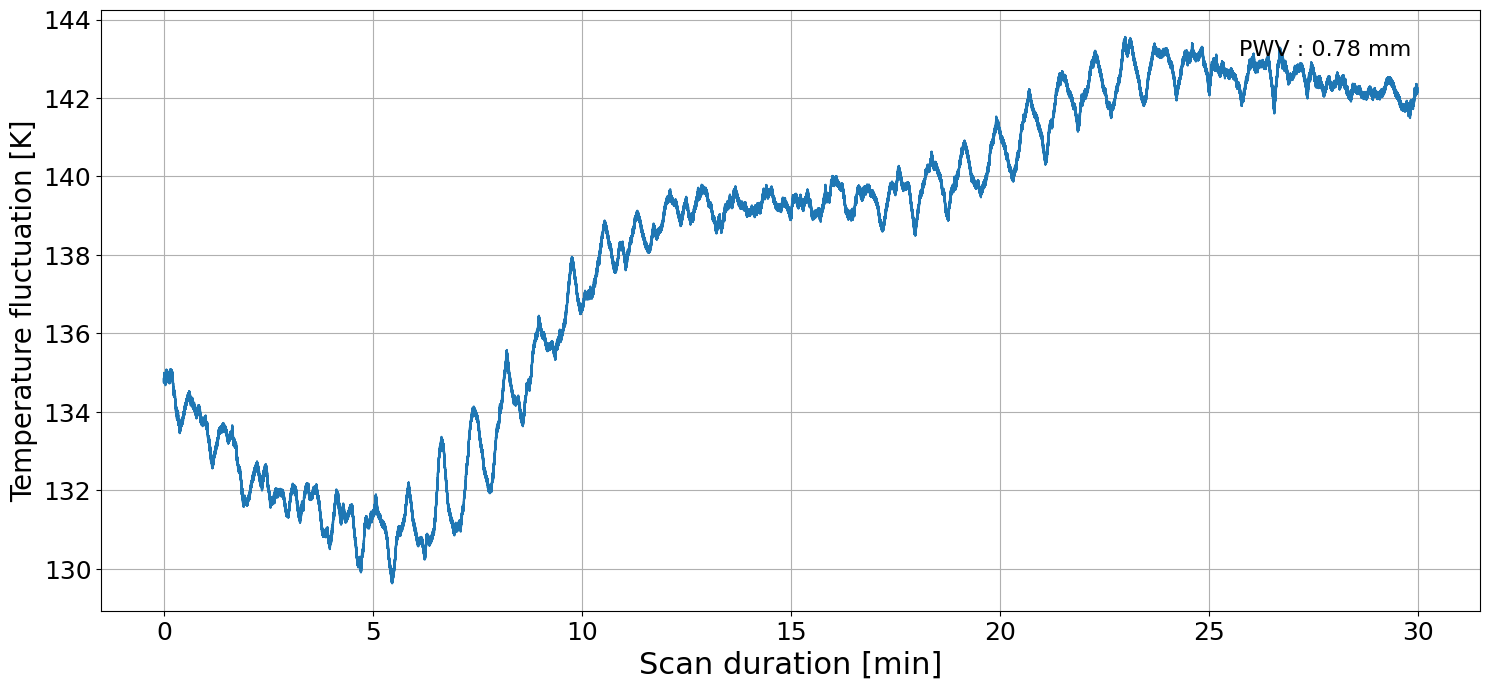

In [9]:
import numpy as np
import matplotlib.pyplot as plt

colors = plt.cm.tab10.colors

# Select observation
obs = data.obs[0]
print(obs.name)

# Metadata
obs_pwv = f"PWV : {obs.telescope.site.weather.pwv:.2f}"

# Data
sig = obs.detdata["signal"]
times = np.asarray(obs.shared["times"])

# Convert time to minutes from start of scan
time_min = (times - times[0]) / 60.0

# Plot only a subset of detectors
dets = obs.all_detectors[::100]

# Plot
fig, ax = plt.subplots(figsize=(15, 7), facecolor="white")

for i, det in enumerate(dets):
    ax.plot(
        time_min,
        sig[det],
        "-",
        label=det,
        color=colors[i % len(colors)],
        linewidth=1.5,
         rasterized=True
    )

ax.set_xlabel("Scan duration [min]", fontsize=22)
ax.set_ylabel("Temperature fluctuation [K]", fontsize=20)

ax.tick_params(axis="both", which="major", labelsize=18)
ax.grid()

ax.text(
    0.95,
    0.95,
    obs_pwv,
    fontsize=16,
    ha="right",
    va="top",
    transform=ax.transAxes,
)

plt.tight_layout()

plt.savefig(
    "plots/tod_280ghz.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [10]:
from scipy.signal import welch
from copy import deepcopy

def calc_alldets_meanPSD(data_2darray, fs=488):
    """
    Calculate the mean Power Spectral Density (PSD) for all detectors using Welch's method.

    Parameters:
    - data_2darray (ndarray): 2D array of shape (n_detectors, n_samples), where each row is the TOD for a detector.
    - fs (float): Sampling frequency in Hz (default is 244).

    Returns:
    - frequencies (ndarray): Array of frequency bins.
    - mean_psd2d (ndarray): Mean PSD across all detectors.
    """
    if data_2darray.shape[0] == 0:
        raise ValueError("Input array has no detectors.")
    
    nperseg = 2**18
    all_psd2d_tod = []
    
    for det_id in range(data_2darray.shape[0]):
        detdata = data_2darray[det_id]
        frequencies, psd2d_tod = welch(detdata, fs=fs, nperseg=nperseg)
        all_psd2d_tod.append(psd2d_tod)
    
    # Convert to array and compute mean PSD
    all_psd2d_tod = np.array(all_psd2d_tod)
    mean_psd2d = np.mean(all_psd2d_tod, axis=0)
    return frequencies, mean_psd2d

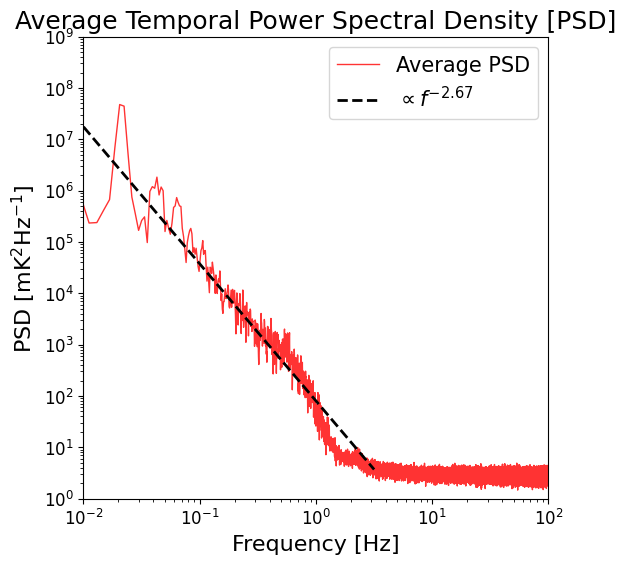

In [12]:
obs = data.obs[0]
### Convert TOD from K to mK
data_level0 = deepcopy(np.asarray(obs.detdata["signal"][:10])) * 1e3
freq_l0_all, ps_l0_all = calc_alldets_meanPSD(data_level0)

# Plot : Power Spectrum
fig1, ax1 = plt.subplots(figsize=(6,6))
ax1.loglog(freq_l0_all, ps_l0_all, 'red', label="Average PSD", 
           linewidth=1, alpha=0.8)

ax1.set_title('Average Temporal Power Spectral Density [PSD]', fontsize=18)
ax1.set_xlabel('Frequency [Hz]', fontsize=16)
ax1.set_ylabel(r'PSD [$\mathrm{mK}^2\mathrm{Hz}^{-1}$]', fontsize=16)


# Generate a slope line (example: y ∝ x^(-1))
alpha = np.round(-8/3.,2)
x_slope = np.logspace(-2, 0.5, 100)  # X range: 10^-2 to 1
y_slope = 8e1 * x_slope**alpha  # Example negative slope (adjust factor as needed)
ax1.loglog(x_slope, y_slope, 'k--', linewidth=2, label=rf"$\propto f^{{{alpha}}}$")

plt.xlim(0.01,100)
plt.ylim(1e0,1e9)
ax1.legend(fontsize=15)
ax1.tick_params(axis='both', labelsize=12)

DEEP56_E50R_08_14-0-0
Best-fit alpha = 3.42
Best-fit white-noise NET = 1.20 mK $\sqrt{s}$
Best-fit f_knee = 2.22 Hz


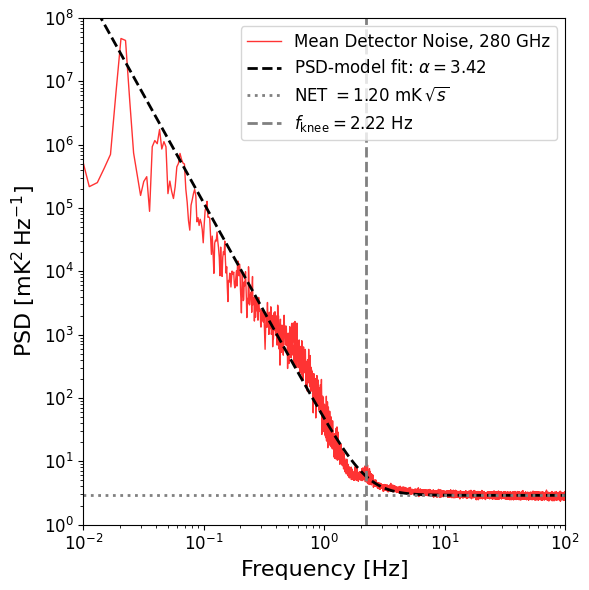

In [14]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

obs = data.obs[0]
print(obs.name)

# Convert TOD from K to mK
data_level0 = deepcopy(np.asarray(obs.detdata["signal"][:])) * 1e3

# Calculate average PSD in mK^2 / Hz
freq_l0_all, ps_l0_all = calc_alldets_meanPSD(data_level0)

# -----------------------------
# Bent 1/f + white-noise model
# -----------------------------
def bent_psd_model(f, white_level, f_knee, alpha):
    """
    PSD model:
        P(f) = P_white * [1 + (f_knee / f)^alpha]

    white_level : mK^2 / Hz
    f_knee      : Hz
    alpha       : positive 1/f slope index
    """
    f = np.asarray(f, dtype=float)

    model = np.full_like(f, np.nan, dtype=float)

    good = (
        np.isfinite(f) &
        (f > 0)
    )

    model[good] = white_level * (1.0 + (f_knee / f[good])**alpha)

    return model


def log_bent_psd_model(f, log_white_level, log_f_knee, alpha):
    white_level = 10**log_white_level
    f_knee = 10**log_f_knee

    model = bent_psd_model(f, white_level, f_knee, alpha)

    return np.log10(model)


# -----------------------------
# Fit full PSD, ignoring f < 0.1 Hz
# -----------------------------
fit_fmin = 0.1
fit_fmax = 80.0

fit_mask = (
    np.isfinite(freq_l0_all) &
    np.isfinite(ps_l0_all) &
    (freq_l0_all > fit_fmin) &
    (freq_l0_all < fit_fmax) &
    (ps_l0_all > 0)
)

f_fit = freq_l0_all[fit_mask]
ps_fit = ps_l0_all[fit_mask]

# -----------------------------
# Initial guesses
# -----------------------------
white_guess_mask = f_fit > 10.0

if np.any(white_guess_mask):
    white_guess = np.median(ps_fit[white_guess_mask])
else:
    white_guess = np.median(ps_fit)

f_knee_guess = 1.0
alpha_guess = 8 / 3

log_p0 = [
    np.log10(white_guess),
    np.log10(f_knee_guess),
    alpha_guess
]

log_bounds = (
    [np.log10(white_guess) - 10, -3.0, 0.1],
    [np.log10(white_guess) + 10,  2.0, 10.0]
)

# -----------------------------
# Fit in log-space
# -----------------------------
popt, pcov = curve_fit(
    log_bent_psd_model,
    f_fit,
    np.log10(ps_fit),
    p0=log_p0,
    bounds=log_bounds,
    maxfev=20000
)

log_white_fit, log_f_knee_fit, alpha_fit = popt

white_level_fit = 10**log_white_fit
f_knee_fit = 10**log_f_knee_fit

# Safe model evaluation for plotting
ps_model_fit = bent_psd_model(
    freq_l0_all,
    white_level_fit,
    f_knee_fit,
    alpha_fit
)
NET = np.sqrt(white_level_fit / 2.0)   # mK sqrt(s)

# -----------------------------
# Print results
# -----------------------------
print(f"Best-fit alpha = {alpha_fit:.2f}")
print(f"Best-fit white-noise NET = {NET:.2f} mK $\sqrt{{s}}$")
print(f"Best-fit f_knee = {f_knee_fit:.2f} Hz")


# -----------------------------
# Plot
# -----------------------------
fig1, ax1 = plt.subplots(figsize=(6, 6))

ax1.loglog(
    freq_l0_all,
    ps_l0_all,
    "red",
    label="Mean Detector Noise, 280 GHz",
    linewidth=1,
    alpha=0.8
)

ax1.loglog(
    freq_l0_all,
    ps_model_fit,
    "k--",
    linewidth=2,
    label=rf"PSD-model fit: $\alpha={alpha_fit:.2f}$"
)

ax1.axhline(
    white_level_fit,
    color="gray",
    linestyle=":",
    linewidth=2,
    label=rf"NET $= {NET:.2f}$ mK$\,\sqrt{{s}}$"
)

ax1.axvline(
    f_knee_fit,
    color="gray",
    linestyle="--",
    linewidth=2,
    label=rf"$f_\mathrm{{knee}}={f_knee_fit:.2f}$ Hz"
)

ax1.set_xlabel("Frequency [Hz]", fontsize=16)
ax1.set_ylabel(r"PSD [$\mathrm{mK}^2\,\mathrm{Hz}^{-1}$]", fontsize=16)

ax1.set_xlim(0.01, 100)
ax1.set_ylim(1e0, 1e8)

ax1.legend(fontsize=12)
ax1.tick_params(axis="both", labelsize=12)

plt.tight_layout()
# plt.savefig(
#     "plots/psd_noise_280ghz.pdf",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()

DEEP56_E50R_08_14-0-0


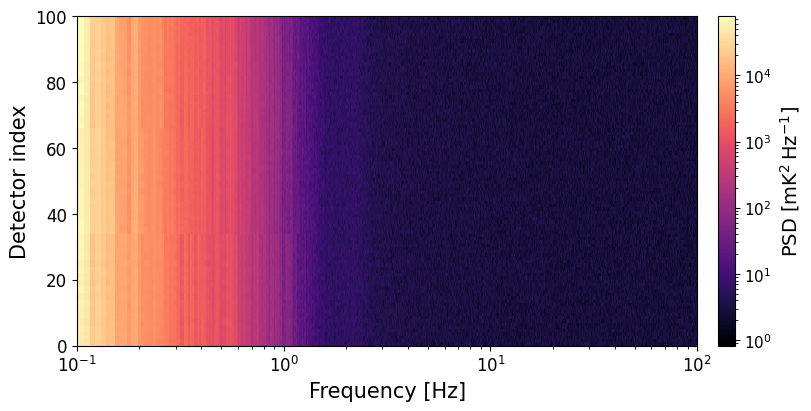

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from matplotlib.colors import LogNorm

# --------------------------------------------------
# Settings
# --------------------------------------------------
obs = data.obs[0]
print(obs.name)

fs = 488                 # sampling frequency [Hz]
fmin_plot = 0.1          # do not show f = 0 on log axis
fmax_plot = 100.0
nperseg = 2**16          # adjust if needed
sort_detectors = False   # set True to sort by white-noise level
savefig = False
outfile = "plots/psd_waterfall_280ghz.pdf"

# --------------------------------------------------
# Helper functions
# --------------------------------------------------
def calc_all_dets_psd_matrix(data_2darray, fs=488, nperseg=2**16):
    """
    Compute one-sided Welch PSD for each detector.

    Parameters
    ----------
    data_2darray : ndarray, shape (n_det, n_samp)
        Detector timestreams in mK.
    fs : float
        Sampling frequency [Hz].
    nperseg : int
        Welch segment length.

    Returns
    -------
    freq : ndarray
        Frequency bins [Hz].
    psd_2d : ndarray, shape (n_det, n_freq)
        PSD for each detector [mK^2 / Hz].
    """
    if data_2darray.ndim != 2:
        raise ValueError("Input must be a 2D array of shape (n_det, n_samp).")

    n_det, n_samp = data_2darray.shape
    if n_det == 0:
        raise ValueError("Input array has no detectors.")

    nperseg = min(nperseg, n_samp)

    psd_list = []
    for i in range(n_det):
        freq, psd = welch(
            data_2darray[i],
            fs=fs,
            nperseg=nperseg,
            detrend="constant",
            scaling="density",
            return_onesided=True,
        )
        psd_list.append(psd)

    psd_2d = np.asarray(psd_list)
    return freq, psd_2d


def log_centers_to_edges(x):
    """
    Convert log-spaced-ish bin centers to edges for pcolormesh.
    """
    lx = np.log10(x)
    edges = np.empty(len(x) + 1)
    edges[1:-1] = 10 ** (0.5 * (lx[:-1] + lx[1:]))
    edges[0] = 10 ** (lx[0] - 0.5 * (lx[1] - lx[0]))
    edges[-1] = 10 ** (lx[-1] + 0.5 * (lx[-1] - lx[-2]))
    return edges


# --------------------------------------------------
# Load data and convert K -> mK
# --------------------------------------------------
tod_mK = np.asarray(obs.detdata["signal"][:1000]) * 1e3   # now in mK
ndets, nsamp = tod_mK.shape

# --------------------------------------------------
# Compute PSD matrix
# --------------------------------------------------
freq, psd_2d = calc_all_dets_psd_matrix(tod_mK, fs=fs, nperseg=nperseg)

# Keep only positive frequencies in desired range
mask = (
    np.isfinite(freq) &
    (freq >= fmin_plot) &
    (freq <= fmax_plot)
)

freq_plot = freq[mask]
psd_plot = psd_2d[:, mask]

# Optional: sort detectors by white-noise level
if sort_detectors:
    white_mask = (freq_plot >= 10.0) & (freq_plot <= min(80.0, fmax_plot))
    if np.any(white_mask):
        white_levels = np.median(psd_plot[:, white_mask], axis=1)
        order = np.argsort(white_levels)
        psd_plot = psd_plot[order]

# --------------------------------------------------
# Plot setup
# --------------------------------------------------
f_edges = log_centers_to_edges(freq_plot)
y_edges = np.arange(psd_plot.shape[0] + 1)

# Robust color scaling
vmin, vmax = np.nanpercentile(psd_plot, [0, 100])
vmin = max(vmin, 1e-6)  # avoid LogNorm issues

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

pcm = ax.pcolormesh(
    f_edges,
    y_edges,
    psd_plot,
    shading="auto",
    cmap="magma",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    rasterized=True,
)

ax.set_xscale("log")
ax.set_xlim(fmin_plot, fmax_plot)
ax.set_ylim(0, psd_plot.shape[0])

ax.set_xlabel("Frequency [Hz]", fontsize=15)
ax.set_ylabel("Detector index", fontsize=15)
# ax.set_title("Frequency-space PSD waterfall", fontsize=16)

ax.tick_params(axis="both", labelsize=12)

cbar = fig.colorbar(pcm, ax=ax, pad=0.01)
cbar.set_label(r"PSD [$\mathrm{mK}^2\,\mathrm{Hz}^{-1}$]", fontsize=14)
cbar.ax.tick_params(labelsize=11)

plt.show()

# --------------------------------------------------
# Save
# --------------------------------------------------
if savefig:
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"Saved: {outfile}")

For Obs 0...
E50R
DEEP56_E50R_08_14-2-0
indigo E50R 

For Obs 1...
E50S
DEEP56_E50S_09_12-2-0
salmon E50S 

For Obs 2...
E60R
DEEP56_E60R_08_22-2-0
blue E60R 

For Obs 3...
E60S
DEEP56_E60S_08_28-2-0
orange E60S 

Saved: plots/rising_setting_ces.pdf


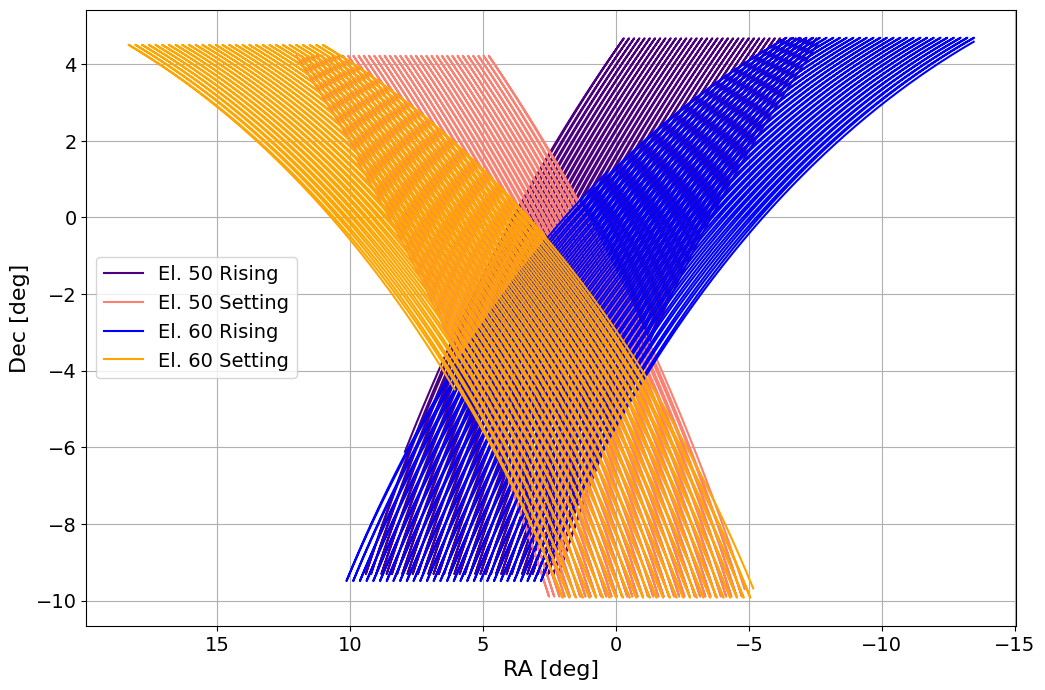

In [55]:
from toast.qarray import to_iso_angles
savefig = False
outfile = "plots/rising_setting_ces.pdf"

fig = plt.figure(figsize=(12, 8))
ax = plt.subplot(111)
col_set = ['orange','salmon']
col_rise = ['blue', 'indigo']
scan_types = ['E50R', 'E50S', 'E60R', 'E60S']

for scan in scan_types:
    for obs_num in range(len(data.obs)):
        sess_name = data.obs[obs_num].session.name
        scan_type = sess_name.split("_")[1]
        if scan==scan_type and sess_name[-3:]:
            print(f"For Obs {obs_num}...")
            print(scan_type)
            print(sess_name)
            scan_r_s = None
            el_name = sess_name.split("_")[1][1:3]
            radec_quats = data.obs[obs_num].shared["boresight_radec"]
            theta, phi, psi = to_iso_angles(radec_quats)
            ra_obs =  np.degrees(phi)
            dec_obs = 90 - np.degrees(theta)
            scan_r_s = 'Rising' if sess_name.split("_")[1].endswith("R") else 'Setting'
            col = col_rise.pop() if scan_r_s == 'Rising' else col_set.pop()
            print(col,scan_type, "\n")
            plt.plot(ra_obs, dec_obs, color=col, 
                     label= f"El. {el_name} {scan_r_s}")
            # break

# Flip the axis#
ax.invert_xaxis()
plt.legend(loc='center left', fontsize=14)

# plt.title('Rising - Setting Scans, CES',fontsize=20)
plt.xlabel('RA [deg]',fontsize=16)
plt.ylabel('Dec [deg]',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
if savefig:
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"Saved: {outfile}")
plt.show()

Plotting Az-El for Obs 0
Plotting Az-El for Obs 1
Plotting Az-El for Obs 2
Plotting Az-El for Obs 3
Saved: plots/az_el_CES.pdf


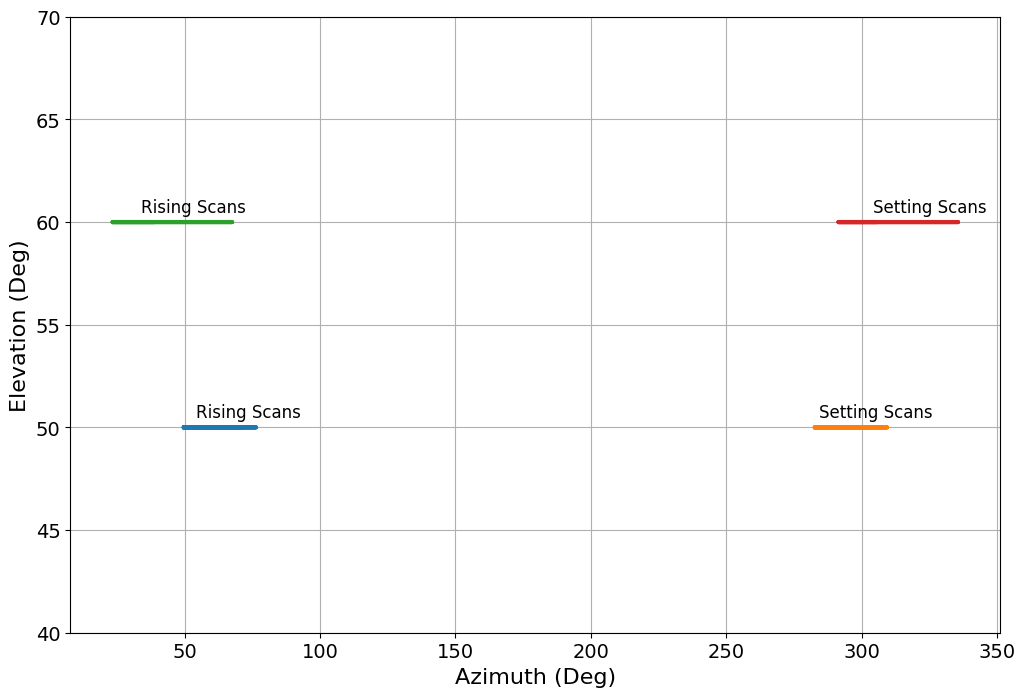

In [61]:
savefig = False
outfile = "plots/az_el_CES.pdf"

fig = plt.figure(figsize=[12, 8])
for obs_num in range(len(data.obs)):
        print(f"Plotting Az-El for Obs {obs_num}")
        az_obs = data.obs[obs_num].shared["azimuth"]
        el_obs = data.obs[obs_num].shared["elevation"]
        plt.plot(np.degrees(az_obs),np.degrees(el_obs), linewidth=3)
        # Annotation near the end of each line

plt.annotate("Rising Scans",  
             xy=(50, 50), 
             textcoords="offset pixels", # how to position the text
             xytext=(1 + 10*1, 10), # distance from text to points (x,y)
             ha='left',
             fontsize=12)

plt.annotate("Setting Scans",  
             xy=(280, 50), 
             textcoords="offset pixels", # how to position the text
             xytext=(1 + 10*1, 10), # distance from text to points (x,y)
             ha='left',
             fontsize=12)

plt.annotate("Rising Scans",  
             xy=(30, 60), 
             textcoords="offset pixels", # how to position the text
             xytext=(1 + 10*1, 10), # distance from text to points (x,y)
             ha='left',
             fontsize=12)

plt.annotate("Setting Scans",  
             xy=(300, 60), 
             textcoords="offset pixels", # how to position the text
             xytext=(1 + 10*1, 10), # distance from text to points (x,y)
             ha='left',
             fontsize=12) 

# Improving the readability of the plot
plt.xlabel('Azimuth (Deg)', fontsize=16)
plt.ylabel('Elevation (Deg)', fontsize=16)
# plt.title('Deep56: Azimuth and Elevation', fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(40,70)
plt.grid(True)
# plt.legend(fontsize=12)
if savefig:
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"Saved: {outfile}")
plt.show()

#### ToDos

In [ ]:
### ToDo
# Hit map [1]
# Cl Noise PS plots
# -----------------
# curvy mod scan
# HitMaps with curvy mod scan
# Maps with curvy mod scan
# Cross-linking plot